In [1]:
import pandas as pd
from wordcloud import WordCloud, STOPWORDS
import matplotlib.pyplot as plt
import os
import sys
# ABY FUNGOVALI relativne importy
root_path = os.path.abspath(os.path.join('..', '..')) 
if root_path not in sys.path:
    sys.path.insert(0, root_path)
__package__ = "source.analysis" 
from .. import DATA_DIR
from ..data.sentiment import return_sentiment_chunk_data

data = return_sentiment_chunk_data(1,False)

In [2]:
# 1. Nastavenie šírky stĺpca (toto funguje globálne)
pd.set_option('display.max_colwidth', None)

# Tvoj zoradený dataframe (ponecháme ho tak, ako je)
sortd = (
    data[data["sentiment_model"] == "roberta"]
    .sort_values("score")
    .set_index("date")
)

# 2. Zobrazenie s fixom (reset_index)
print("--- TOP 10 DOVISH CHUNKS (Najviac negatívne) ---")
# Reset_index zabezpečí unikátne ID riadkov pre Styler
display(sortd.head(10).reset_index().style.set_properties(**{'text-align': 'left'}))

--- TOP 10 DOVISH CHUNKS (Najviac negatívne) ---


,date,part,is_question,chunk,score,sentiment_model
0,2000-10-05 00:00:00,IS,0,"As mentioned at our last meeting, some uncertainty about short-term growth dynamics stems from oil price developments, as is reflected in survey or confidence data .",-0.976955,roberta
1,2011-07-07 00:00:00,QA,1,"Related to that, doesn’t this raise the possibility or the danger of moral hazard because the governments in these countries might count on the ECB instead of pursuing their reforms on the fiscal side?",-0.976423,roberta
2,2004-03-04 00:00:00,IS,0,"Moreover, the prevailing uncertainties surrounding fiscal policies and structural reforms in some euro area countries may have had a negative impact on consumer sentiment.",-0.976190,roberta
3,2010-03-04 00:00:00,QA,1,"Also is this uncertainty about what the aid package will really be, what the interest rates will be on the loans, that the IMF is involved and nobody really knows what the role will be, is this part of the reason for what we are seeing in the market right now, with CDSs just sky-rocketing?",-0.976146,roberta
4,2015-07-16 00:00:00,QA,0,"So lower commodity prices, a stronger euro, a somewhat lower growth, have increased the risk to a sustainable path of inflation towards 2%.",-0.975849,roberta
5,2013-05-02 00:00:00,QA,0,"On the second question, one reason why banks do not lend is risk aversion, which is both micro, with respect to their clients, and macro, with respect to the general economic environment and the high uncertainty that still prevails in some parts of the euro area.",-0.975809,roberta
6,2018-09-13 00:00:00,QA,0,Then of course you have weakening funding conditions as well and all this is going to translate into different lending terms.,-0.975651,roberta
7,2022-12-15 00:00:00,QA,1,"There are lots of deflationary, or at least disinflationary, forces in the economy, so why would you set a guidance without having seen your projections, and why would you keep on providing a guidance when you said you would stop doing it?",-0.975602,roberta
8,1998-12-01 00:00:00,IS,0,"On the one hand, downward risks relate to the global environment and potential repercussions on the euro area, for example via import prices and further pressure on producer prices.",-0.974810,roberta
9,2009-08-06 00:00:00,IS,0,"In addition, the relatively steep yield curve and the re-emergence of risk appetite, reflected particularly in the increase in stock prices over the past few months, may have dampened M3 growth to some extent.",-0.974763,roberta


In [44]:
print("\n--- TOP 10 HAWKISH CHUNKS (Najviac pozitívne) ---")
display(sortd.tail(10).reset_index().style.set_properties(**{'text-align': 'left'}))


--- TOP 10 HAWKISH CHUNKS (Najviac pozitívne) ---


,date,part,is_question,chunk,score,sentiment_model
0,2015-07-16 00:00:00,IS,0,Loan dynamics continued to improve.,0.943721,finbert
1,2015-06-03 00:00:00,IS,0,Loan dynamics continued to improve.,0.943721,finbert
2,2015-09-03 00:00:00,IS,0,Loan dynamics continued to improve.,0.943721,finbert
3,2005-12-01 00:00:00,IS,0,"The growth of loans to the private sector – and, in particular, mortgage borrowing – has strengthened further over recent months, from already rapid rates of growth.",0.943833,finbert
4,2025-09-11 00:00:00,IS,0,"The services sector continued to grow, boosted by strong tourism and, especially, by a pick-up in digital services.",0.944059,finbert
5,2015-03-05 00:00:00,IS,0,Loan dynamics also gradually improved further.,0.944333,finbert
6,2013-04-04 00:00:00,QA,0,"And by the way, in Germany, there has been an improvement across the board.",0.944743,finbert
7,2020-06-04 00:00:00,QA,0,Overall you have really a significant improvement.,0.945099,finbert
8,2013-08-01 00:00:00,QA,0,Market sentiment continues to improve.,0.945675,finbert
9,2002-05-02 00:00:00,IS,0,"Moreover, business and consumer confidence has strengthened again more recently, as reflected in the data published by the Commission.",0.945776,finbert


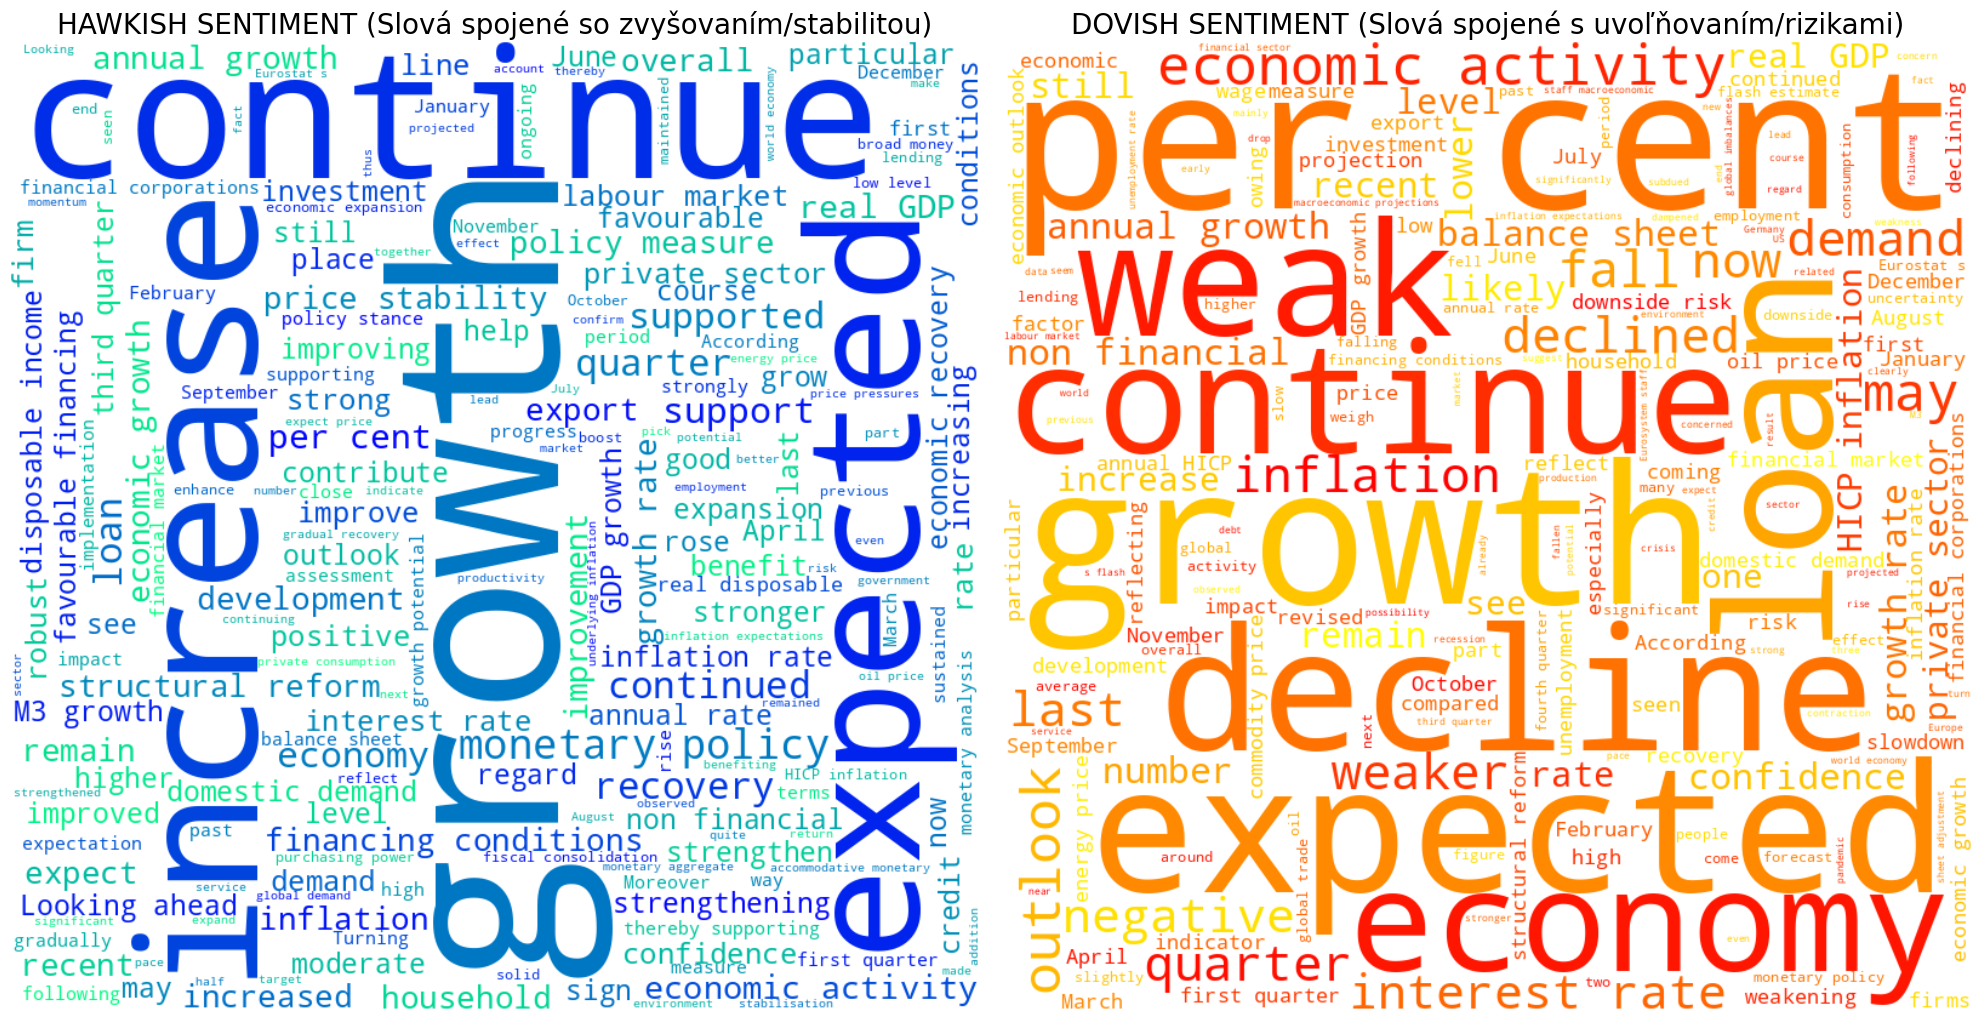

In [ ]:
# 1. Príprava dát - vyberieme si napr. finbert (aby sme neduplikovali texty)
# Môžeš zmeniť na 'roberta', ak chceš vidieť jej pohľad
df_model = data[data['sentiment_model'] == 'finbert'].copy()#[data['topic'] != 'OTHER_IRRELEVANT']

# 2. Definícia stop-words (použijeme tie, čo sme minule vybrali)
custom_stopwords = set(STOPWORDS) | set( 
    [
    # Procedurálne slová (v n-gramoch svietia najviac)
    'question', 'questions', 'second', 'mr', 'president', 'vice', 'lady', 'gentlemen', 
    'governing', 'council', 'meeting', 'press', 'conference', 'today', 'said', 'say', 
    'think', 'thank', 'afternoon', 'floor', 'disposal', 'decided', 'decision',
    
    # Inštitucionálny balast (všetci vedia, že je to ECB v Eurozóne)
    'ecb', 'euro', 'area', 'european', 'central', 'bank', 'banks', 'countries', 
    'member', 'states', 'united', 'states', 'national',
    
    # Časové a pomocné výrazy
    'term', 'medium', 'short', 'long', 'longer', 'time', 'year', 'years', 'month', 
    'months', 'current', 'basis', 'point', 'points', 'actually', 'going', 'will', 
    'well', 'just', 'look', 'take', 'need', 'believe'
])

# 3. Rozdelenie na Hawkish a Dovish
# Prah (threshold) 0.1 je fajn, ale môžeš experimentovať (napr. 0.05)
hawkish_text = " ".join(df_model[df_model['score'] > 0.9]['chunk'].astype(str))
dovish_text = " ".join(df_model[df_model['score'] < -0.9]['chunk'].astype(str))

def plot_sentiment_wordclouds(text_pos, text_neg):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 10))

    # Hawkish Wordcloud (Zelená/Modrá - "Prísny" tón)
    wc_pos = WordCloud(width=800, height=800, background_color='white', 
                       stopwords=custom_stopwords, colormap='winter').generate(text_pos)
    ax1.imshow(wc_pos, interpolation='bilinear')
    ax1.set_title('HAWKISH SENTIMENT (Slová spojené so zvyšovaním/stabilitou)', fontsize=20)
    ax1.axis("off")

    # Dovish Wordcloud (Červená/Oranžová - "Uvoľnený" tón)
    wc_neg = WordCloud(width=800, height=800, background_color='white', 
                       stopwords=custom_stopwords, colormap='autumn').generate(text_neg)
    ax2.imshow(wc_neg, interpolation='bilinear')
    ax2.set_title('DOVISH SENTIMENT (Slová spojené s uvoľňovaním/rizikami)', fontsize=20)
    ax2.axis("off")

    plt.tight_layout()
    plt.show()

# Spustenie
plot_sentiment_wordclouds(hawkish_text, dovish_text)

In [19]:
from sklearn.feature_extraction.text import CountVectorizer

def get_sentiment_context(df, label, top_k=15):
    # n=2 nám dá bigramy (kontext)
    vec = CountVectorizer(ngram_range=(2, 2), stop_words=list(custom_stopwords)).fit(df)
    bag_of_words = vec.transform(df)
    sum_words = bag_of_words.sum(axis=0) 
    words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
    return sorted(words_freq, key = lambda x: x[1], reverse=True)[:top_k]

# Rozdelíme si dáta
hawkish_chunks = df_model[df_model['score'] > 0.3]['chunk'].astype(str)
dovish_chunks = df_model[df_model['score'] < -0.3]['chunk'].astype(str)

print("--- KONTEXT HAWKISH (Jastraby) ---")
for phrase, freq in get_sentiment_context(hawkish_chunks, "Hawkish"):
    print(f"{phrase}: {freq}")

print("\n--- KONTEXT DOVISH (Holubice) ---")
for phrase, freq in get_sentiment_context(dovish_chunks, "Dovish"):
    print(f"{phrase}: {freq}")

--- KONTEXT HAWKISH (Jastraby) ---


/home/kubovotny/Documents/School/bachelor-thesis/.venv/lib/python3.12/site-packages/sklearn/feature_extraction/text.py:411: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['aren', 'couldn', 'didn', 'doesn', 'don', 'hadn', 'hasn', 'haven', 'isn', 'let', 'll', 'mustn', 're', 'shan', 'shouldn', 've', 'wasn', 'weren', 'won', 'wouldn'] not in stop_words.
  warnings.warn(


monetary policy: 456
price stability: 322
structural reforms: 235
economic activity: 234
interest rates: 223
real gdp: 209
economic growth: 188
financing conditions: 184
labour market: 160
economic analysis: 154
policy measures: 145
private sector: 139
inflation expectations: 138
per cent: 135
growth rate: 127

--- KONTEXT DOVISH (Holubice) ---
monetary policy: 1863
price stability: 1401
interest rates: 1348
inflation expectations: 505
interest rate: 474
per cent: 449
exchange rate: 399
risks price: 378
oil prices: 364
inflation rates: 357
hicp inflation: 346
price developments: 316
upside risks: 283
forward guidance: 277
downside risks: 274


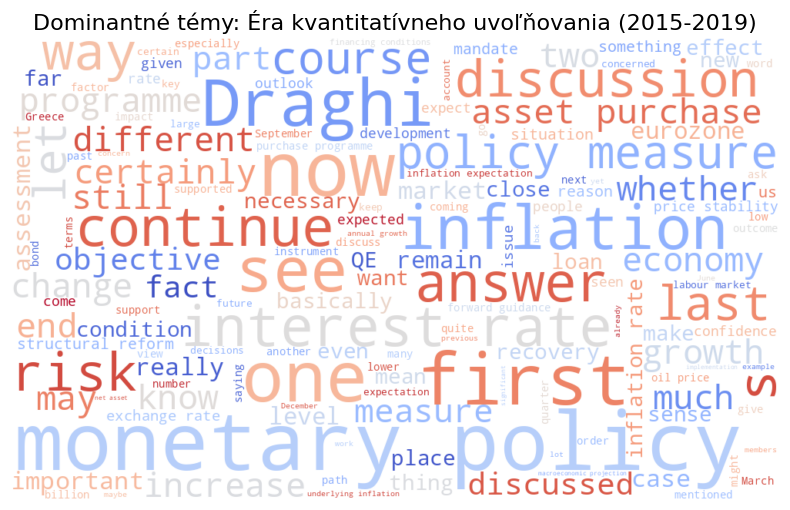

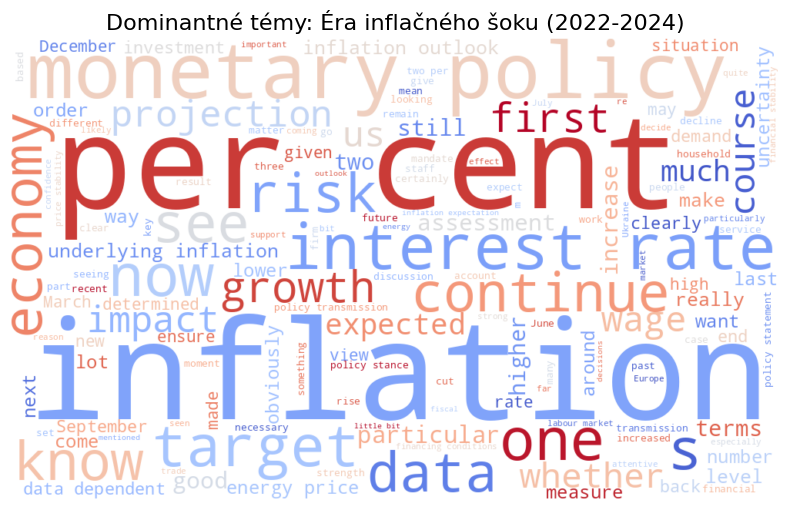

In [48]:


# 1. Načítanie dát
df_scraped = pd.read_csv(f'{DATA_DIR}/scraped_v2.psv',sep="|")
df_scraped['date'] = pd.to_datetime(df_scraped['date'])

# 2. Definícia stop-words (balast, ktorý nechceme)


def generate_ecb_wordcloud(text_data, title):
    # Pridáme základné anglické stop-words z wordcloudu
    from wordcloud import STOPWORDS
    final_stopwords = STOPWORDS.union(set(custom_stopwords))
    
    wc = WordCloud(
        width=1000, height=600, 
        background_color='white',
        stopwords=final_stopwords,
        colormap='coolwarm', # Modrá (Dovish) -> Červená (Hawkish) feeling
        max_words=150
    ).generate(text_data)
    
    plt.figure(figsize=(10, 6))
    plt.imshow(wc, interpolation='bilinear')
    plt.axis("off")
    plt.title(title, fontsize=16)
    plt.show()

# --- ANALÝZA 1: Éra nízkej inflácie (napr. 2015-2019) ---
era_low = df_scraped[(df_scraped['date'] > '2015-01-01') & (df_scraped['date'] < '2020-01-01')]
text_low = " ".join(era_low['intro'].fillna('') + " " + era_low['qa'].fillna(''))
generate_ecb_wordcloud(text_low, "Dominantné témy: Éra kvantitatívneho uvoľňovania (2015-2019)")

# --- ANALÝZA 2: Éra inflačného šoku (2022-2024) ---
era_high = df_scraped[df_scraped['date'] >= '2022-01-01']
text_high = " ".join(era_high['intro'].fillna('') + " " + era_high['qa'].fillna(''))
generate_ecb_wordcloud(text_high, "Dominantné témy: Éra inflačného šoku (2022-2024)")

In [12]:
from sklearn.feature_extraction.text import CountVectorizer
import pandas as pd

def get_top_ngrams(corpus, n, top_k):
    # n=2 sú bigramy (dvojice), n=3 trigramy (trojice)
    vec = CountVectorizer(ngram_range=(n, n), stop_words='english').fit(corpus)
    bag_of_words = vec.transform(corpus)
    sum_words = bag_of_words.sum(axis=0) 
    words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
    words_freq = sorted(words_freq, key = lambda x: x[1], reverse=True)
    return words_freq[:top_k]

# Načítaj texty (napr. z tvojho text_high pre inflačnú éru)
corpus = [text_high] # text_high musí byť list alebo series

print("Najčastejšie bigramy:")
print(get_top_ngrams(corpus, 2, 20))

print("\nNajčastejšie trigramy:")
print(get_top_ngrams(corpus, 3, 20))

Najčastejšie bigramy:
[('monetary policy', np.int64(701)), ('medium term', np.int64(360)), ('governing council', np.int64(319)), ('euro area', np.int64(287)), ('second question', np.int64(234)), ('underlying inflation', np.int64(181)), ('inflation outlook', np.int64(179)), ('data dependent', np.int64(145)), ('term target', np.int64(137)), ('basis points', np.int64(131)), ('policy transmission', np.int64(121)), ('energy prices', np.int64(120)), ('meeting meeting', np.int64(106)), ('policy statement', np.int64(104)), ('key ecb', np.int64(93)), ('ecb rates', np.int64(93)), ('vice president', np.int64(92)), ('policy stance', np.int64(90)), ('financing conditions', np.int64(88)), ('term inflation', np.int64(84))]

Najčastejšie trigramy:
[('medium term target', np.int64(137)), ('monetary policy transmission', np.int64(117)), ('monetary policy statement', np.int64(102)), ('key ecb rates', np.int64(93)), ('monetary policy stance', np.int64(84)), ('assessment inflation outlook', np.int64(70)), 

In [13]:
custom_stopwords.extend(['will', 'shall', 'going', 'think', 'look', 'want', 'need', 'say', 'said', 'weve', 'youre'])

In [14]:
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer
# Spojíme všetko do jedného veľkého textu (odstránime NaN)
full_text = " ".join(df_scraped['intro'].fillna('') + " " + df_scraped['qa'].fillna(''))

def print_top_ngrams(text, n, top_k):
    # n=1: slová, n=2: dvojice, n=3: trojice
    # stop_words='english' vyhodí základné slová ako "the", "a", "is"...
    vec = CountVectorizer(ngram_range=(n, n), stop_words='english').fit([text])
    bag_of_words = vec.transform([text])
    sum_words = bag_of_words.sum(axis=0) 
    words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
    words_freq = sorted(words_freq, key = lambda x: x[1], reverse=True)
    
    print(f"\n--- TOP {top_k} N-GRAMS (n={n}) ---")
    for i, (word, freq) in enumerate(words_freq[:top_k]):
        print(f"{i+1}. {word}: {freq}")

# 2. Vypíšeme si zoznamy
print_top_ngrams(full_text, n=1, top_k=30) # Jednotlivé slová
print_top_ngrams(full_text, n=2, top_k=30) # Dvojice
print_top_ngrams(full_text, n=3, top_k=30) # Trojice


--- TOP 30 N-GRAMS (n=1) ---
1. question: 9206
2. euro: 7572
3. inflation: 7513
4. growth: 6281
5. monetary: 6115
6. area: 5504
7. policy: 5183
8. rates: 5000
9. ecb: 4578
10. price: 4456
11. council: 4430
12. said: 4323
13. term: 4320
14. rate: 4220
15. second: 3991
16. governing: 3891
17. economic: 3879
18. time: 3765
19. stability: 3633
20. say: 3580
21. think: 3258
22. market: 3066
23. today: 2938
24. medium: 2911
25. financial: 2791
26. economy: 2708
27. risks: 2689
28. year: 2600
29. banks: 2563
30. countries: 2462

--- TOP 30 N-GRAMS (n=2) ---
1. euro area: 5315
2. governing council: 3879
3. monetary policy: 3618
4. price stability: 2621
5. medium term: 2330
6. second question: 1950
7. inflation expectations: 918
8. central bank: 912
9. question mr: 766
10. central banks: 761
11. vice president: 741
12. exchange rate: 726
13. structural reforms: 708
14. economic activity: 678
15. inflation rates: 649
16. short term: 602
17. policy stance: 576
18. financing conditions: 568
19. e

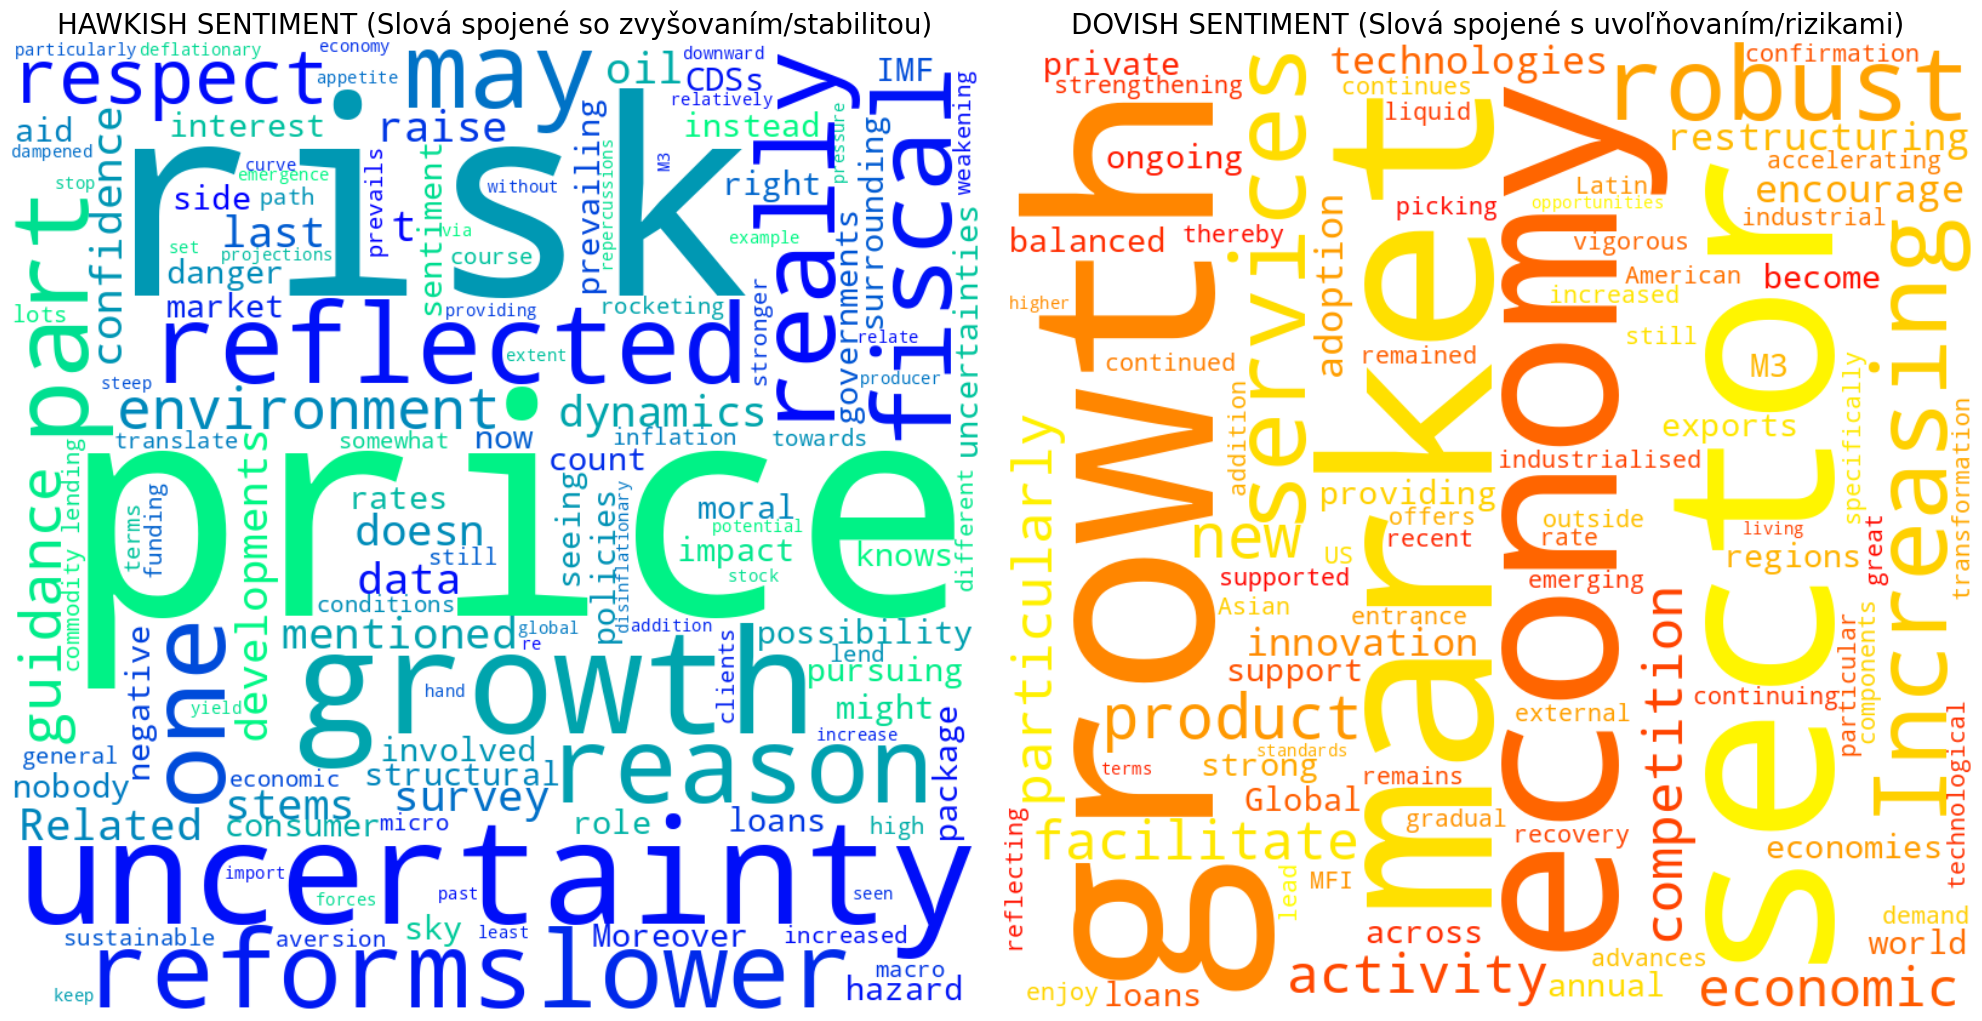

In [3]:
# 1. Príprava dát - vyberieme si napr. finbert (aby sme neduplikovali texty)
# Môžeš zmeniť na 'roberta', ak chceš vidieť jej pohľad
df_model = sortd.copy()

# 2. Definícia stop-words (použijeme tie, čo sme minule vybrali)
custom_stopwords = set(STOPWORDS) | set( 
    [
    # Procedurálne slová (v n-gramoch svietia najviac)
    'question', 'questions', 'second', 'mr', 'president', 'vice', 'lady', 'gentlemen', 
    'governing', 'council', 'meeting', 'press', 'conference', 'today', 'said', 'say', 
    'think', 'thank', 'afternoon', 'floor', 'disposal', 'decided', 'decision',
    
    # Inštitucionálny balast (všetci vedia, že je to ECB v Eurozóne)
    'ecb', 'euro', 'area', 'european', 'central', 'bank', 'banks', 'countries', 
    'member', 'states', 'united', 'states', 'national',
    
    # Časové a pomocné výrazy
    'term', 'medium', 'short', 'long', 'longer', 'time', 'year', 'years', 'month', 
    'months', 'current', 'basis', 'point', 'points', 'actually', 'going', 'will', 
    'well', 'just', 'look', 'take', 'need', 'believe'
])

# 3. Rozdelenie na Hawkish a Dovish
# Prah (threshold) 0.1 je fajn, ale môžeš experimentovať (napr. 0.05)
hawkish_text = " ".join(df_model.head(10)['chunk'].astype(str))
dovish_text = " ".join(df_model.tail(10)['chunk'].astype(str))

def plot_sentiment_wordclouds(text_pos, text_neg):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 10))

    # Hawkish Wordcloud (Zelená/Modrá - "Prísny" tón)
    wc_pos = WordCloud(width=800, height=800, background_color='white', 
                       stopwords=custom_stopwords, colormap='winter').generate(text_pos)
    ax1.imshow(wc_pos, interpolation='bilinear')
    ax1.set_title('HAWKISH SENTIMENT (Slová spojené so zvyšovaním/stabilitou)', fontsize=20)
    ax1.axis("off")

    # Dovish Wordcloud (Červená/Oranžová - "Uvoľnený" tón)
    wc_neg = WordCloud(width=800, height=800, background_color='white', 
                       stopwords=custom_stopwords, colormap='autumn').generate(text_neg)
    ax2.imshow(wc_neg, interpolation='bilinear')
    ax2.set_title('DOVISH SENTIMENT (Slová spojené s uvoľňovaním/rizikami)', fontsize=20)
    ax2.axis("off")

    plt.tight_layout()
    plt.show()

# Spustenie
plot_sentiment_wordclouds(hawkish_text, dovish_text)